# Graphs for M.Sc. Thesis

### Mapping the Trajectories of the Yield.

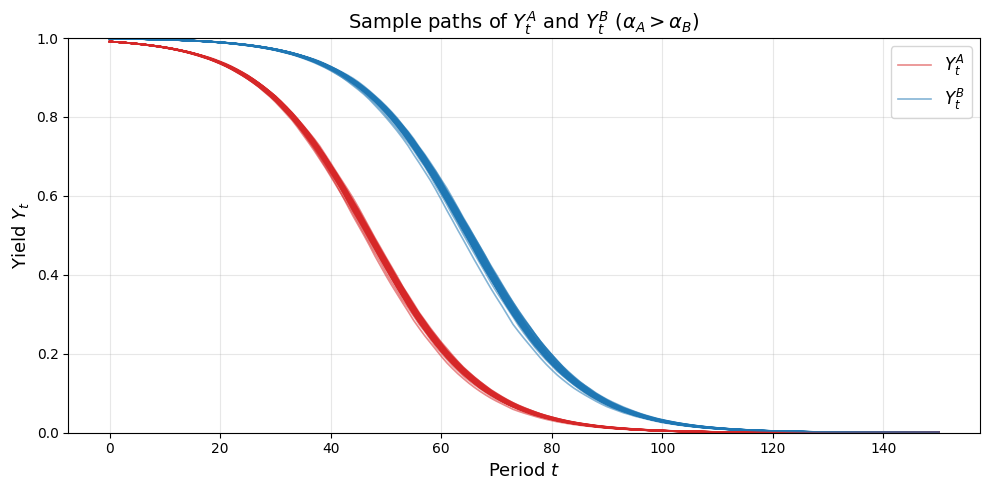

In [4]:
# Parameters
S0    = 0.01
mu    = 0.10
sigma = 0.005
alpha_A = 0.90   # Machine A degrades faster
alpha_B = 0.15   # Machine B degrades slower
T     = 150       # periods
n_paths = 50
seed  = 42

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed)
dt  = 1.0
t   = np.arange(T + 1)

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(n_paths):
    Z  = rng.standard_normal(T)
    S  = np.empty(T + 1); S[0] = S0
    for k in range(T):
        S[k+1] = S[k] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[k])

    YA = 1 / (1 + alpha_A * S)
    YB = 1 / (1 + alpha_B * S)

    ax.plot(t, YA, color="tab:red",  alpha=0.55, linewidth=1.2,
            label="$Y_t^A$" if i == 0 else "")
    ax.plot(t, YB, color="tab:blue", alpha=0.55, linewidth=1.2,
            label="$Y_t^B$" if i == 0 else "")

ax.set_xlabel("Period $t$", fontsize=13)
ax.set_ylabel("Yield $Y_t$", fontsize=13)
ax.set_title("Sample paths of $Y_t^A$ and $Y_t^B$ ($\\alpha_A > \\alpha_B$)", fontsize=14)
ax.set_ylim(0, 1)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("yield_paths.png", dpi=150)
plt.show()

In [ ]:
from scipy import integrate

# ── Analytical E[Y_t] via numerical integration over lognormal density ──────
def E_yield(alpha, t, S0, mu, sigma, n_points=2000):
    m = np.log(S0) + (mu - 0.5 * sigma**2) * t
    s = sigma * np.sqrt(t)
    s_max  = np.exp(m + 6 * s)
    s_grid = np.linspace(1e-12, s_max, n_points)
    log_pdf = -0.5 * ((np.log(s_grid) - m) / s) ** 2 - np.log(s_grid * s * np.sqrt(2 * np.pi))
    pdf     = np.exp(log_pdf)
    y       = 1.0 / (1.0 + alpha * s_grid)
    return integrate.trapezoid(y * pdf, s_grid)

t_grid = np.arange(T + 1)

EYA_analytical = np.array([E_yield(alpha_A, t, S0, mu, sigma) for t in t_grid])
EYB_analytical = np.array([E_yield(alpha_B, t, S0, mu, sigma) for t in t_grid])

# ── Plot yield gap only ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

gap_analytical = EYB_analytical - EYA_analytical
ax.plot(t_grid, gap_analytical, color="purple", linewidth=2.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Period $t$", fontsize=12)
ax.set_ylabel(r"$\mathbb{E}[Y_t^B] - \mathbb{E}[Y_t^A]$", fontsize=12)
ax.set_title("Yield gap between Machine B and Machine A", fontsize=13)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("supermartingale_decay.png", dpi=150)
plt.show()

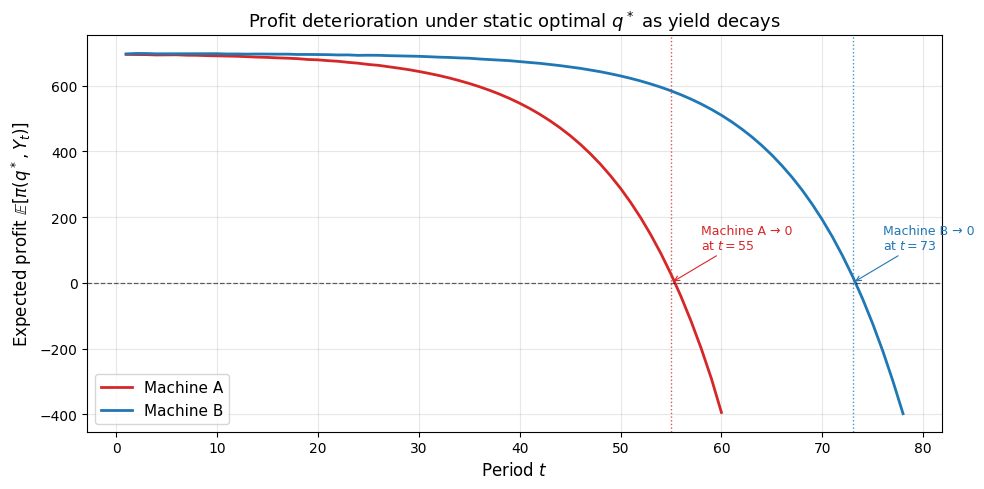

In [7]:
from scipy.optimize import brentq

# ── Parameters for profit function ──────────────────────────────────────────
P       = 10
gamma   = 4
h       = 1
c_input = 3
D       = 100

# ── Compute truncated moments via simulation for a given (alpha, t) ──────────
def compute_expected_profit(q, alpha, t, n_sim=50000):
    m = np.log(S0) + (mu - 0.5 * sigma**2) * t
    s = sigma * np.sqrt(t)
    Z = rng.standard_normal(n_sim)
    S_T = np.exp(m + s * Z)
    Y   = 1.0 / (1.0 + alpha * S_T)
    output = Y * q
    revenue  = P * np.minimum(D, output)
    holding  = h * np.maximum(output - D, 0)
    penalty  = gamma * np.maximum(D - output, 0)
    cost     = c_input * q
    return np.mean(revenue - holding - penalty - cost)

# ── Find static q* at each t via bisection on the FOC ────────────────────────
def find_q_star(alpha, t, n_sim=50000):
    def foc(q):
        eps = 1.0
        return (compute_expected_profit(q + eps, alpha, t, n_sim) -
                compute_expected_profit(q - eps, alpha, t, n_sim)) / (2 * eps)
    try:
        return brentq(foc, 1, 500, xtol=0.5)
    except ValueError:
        return np.nan

# ── Evaluate over t_grid ──────────────────────────────────────────────────────
profit_A = np.empty(len(t_grid))
profit_B = np.empty(len(t_grid))

for i, t in enumerate(t_grid):
    q_star_A = find_q_star(alpha_A, t)
    q_star_B = find_q_star(alpha_B, t)
    profit_A[i] = compute_expected_profit(q_star_A, alpha_A, t)
    profit_B[i] = compute_expected_profit(q_star_B, alpha_B, t)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_grid, profit_A, color="tab:red",  linewidth=2.0, label="Machine A")
ax.plot(t_grid, profit_B, color="tab:blue", linewidth=2.0, label="Machine B")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)

# Mark where each machine crosses zero
for profit, color, label in [(profit_A, "tab:red", "A"), (profit_B, "tab:blue", "B")]:
    cross = np.where(np.diff(np.sign(profit)))[0]
    if len(cross) > 0:
        t_cross = t_grid[cross[0]]
        ax.axvline(t_cross, color=color, linewidth=1.0, linestyle=":", alpha=0.8)
        ax.annotate(f"Machine {label} → 0\nat $t={t_cross}$",
                    xy=(t_cross, 0), xytext=(t_cross + 3, max(profit_A) * 0.15),
                    fontsize=9, color=color,
                    arrowprops=dict(arrowstyle="->", color=color, lw=0.8))

ax.set_xlabel("Period $t$", fontsize=12)
ax.set_ylabel("Expected profit $\\mathbb{E}[\\pi(q^*, Y_t)]$", fontsize=12)
ax.set_title("Profit deterioration under static optimal $q^*$ as yield decays", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("profit_deterioration.png", dpi=150)
plt.show()

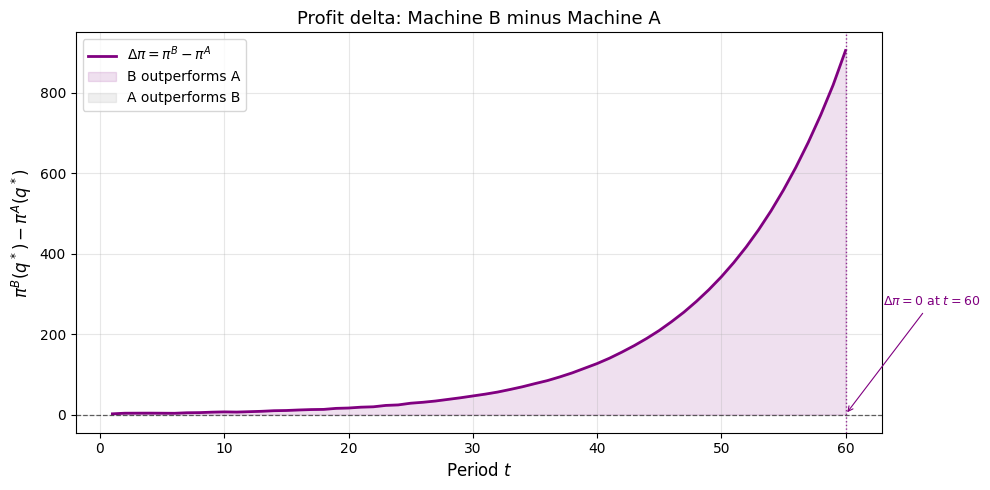

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

delta = profit_B - profit_A
ax.plot(t_grid, delta, color="purple", linewidth=2.0, label=r"$\Delta\pi = \pi^B - \pi^A$")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)
ax.fill_between(t_grid, delta, 0,
                where=(delta >= 0), color="purple", alpha=0.12, label="B outperforms A")
ax.fill_between(t_grid, delta, 0,
                where=(delta < 0),  color="gray",   alpha=0.12, label="A outperforms B")

cross_delta = np.where(np.diff(np.sign(delta)))[0]
if len(cross_delta) > 0:
    t_cross_delta = t_grid[cross_delta[0]]
    ax.axvline(t_cross_delta, color="purple", linewidth=1.0, linestyle=":", alpha=0.8)
    ax.annotate(f"$\\Delta\\pi = 0$ at $t={t_cross_delta}$",
                xy=(t_cross_delta, 0), xytext=(t_cross_delta + 3, max(delta) * 0.3),
                fontsize=9, color="purple",
                arrowprops=dict(arrowstyle="->", color="purple", lw=0.8))

ax.set_xlabel("Period $t$", fontsize=12)
ax.set_ylabel(r"$\pi^B(q^*) - \pi^A(q^*)$", fontsize=12)
ax.set_title("Profit delta: Machine B minus Machine A", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("profit_delta.png", dpi=150)
plt.show()
